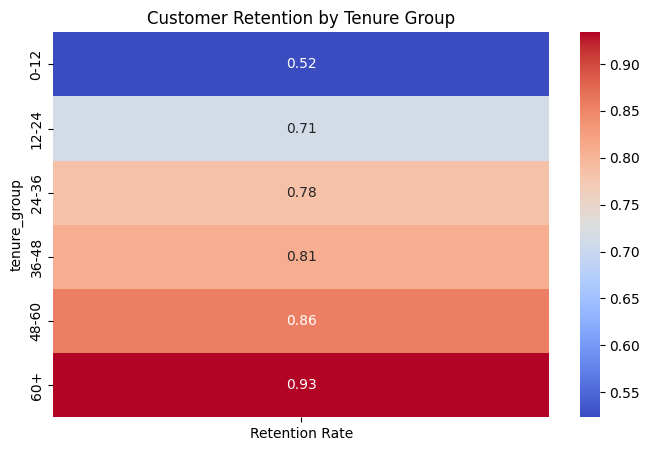

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Telco_Customer_Churn.csv")


# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop null values
df = df.dropna()

# Grouping by Tenure
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,36,48,60,72],
                           labels=['0-12','12-24','24-36','36-48','48-60','60+'])

cohort.columns
# Create cohort table
cohort = df.groupby(['tenure_group', 'Churn']).size().unstack(fill_value=0)

# Rename columns
cohort.columns = ['Retained', 'Churned']

# Create retention rate
cohort['Retention Rate'] = cohort['Retained'] / (cohort['Retained'] + cohort['Churned'])

# Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(cohort[['Retention Rate']], 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm")

plt.title("Customer Retention by Tenure Group")
plt.show()


## 🔍 Key Insights

- Customers in the 0–12 month tenure group show the highest churn rate.
- Retention improves significantly after 24 months.
- Long-term customers (48+ months) are highly loyal.
- Early-stage customer experience plays a critical role in retention.

## 💡 Step 3: Business Recommendations

- Improve onboarding experience for new users
- Offer discounts for annual plans
- Introduce loyalty programs
- Target high-risk churn segments early